# Glacier Hydraulic Tremor
This notebook starts the identification of glacier hydraulic tremor at Eqalorutsit Kangilliit Sermiat (Qajuuttap Sermia). We have 3 seismometers installed: QJT01, QJT02, QJT03 with the components 'HHZ','HHN','HHE' for the vertical, north, and east component of each seismometer. The sampling frequency is 200Hz.

In [14]:
import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import matplotlib
import datetime
import obspy
import seaborn as sns
import math
import datetime
from obspy import UTCDateTime
from obspy.clients.filesystem.sds import Client
from multiprocessing import Pool
import statsmodels.api as sm
import statsmodels.formula.api as smf

## Week 20

In [16]:
times = np.load("results_all_z_new/0.npz", allow_pickle = True)["times"]
GHTs = np.load("results_all_z_new/0.npz", allow_pickle = True)["GHT"]
for i in range(1, 354):
    times = np.hstack((times, np.load("results_all_z_new/" + str(i) + ".npz", allow_pickle = True)["times"]))
    GHTs = np.dstack((GHTs, np.load("results_all_z_new/" + str(i) + ".npz", allow_pickle = True)["GHT"]))
    print(str(i), end = '\r')

times = times[0]
np.shape(GHTs)
np.shape(times)
# GHTs

(50976,)

In [17]:
freqbounds = [(1, 4), (4, 7), (7, 10)]
stations = ['QJT01', 'QJT02', 'QJT03']

# Calculate mean GHT between stations
df_list = []

# Put GHT data into DataFrames
for idx1, freqbound in enumerate(freqbounds):
    for idx2, station in enumerate(stations):
      t = times.copy()
      GHT = GHTs[idx1, idx2, :].copy()
      print(np.shape(GHT))
      print(np.shape(t))
      df = pd.DataFrame(data=GHT, index=t, columns = [(freqbound, station)])
      df_alt = df.iloc[:-2] 
      df_list.append(df)

# Merge the three DataFrames into a single one
df_ght = pd.concat(df_list, axis='columns')

# Normalization
df_ght = df_ght.divide(df_ght.median(skipna=True))

# Rolling averaging for each station
df_ght = df_ght.rolling('6h', center=True).median()

df_ght.iloc[:, [0, 3, 6]] = df_ght.iloc[:, [0, 3, 6]] / df_ght.iloc[:, [0, 3, 6]].sum().sum()

df_ght.iloc[:, [1, 4, 7]] = df_ght.iloc[:, [1, 4, 7]] / df_ght.iloc[:, [1, 4, 7]].sum().sum()

df_ght.iloc[:, [2, 5, 8]] = df_ght.iloc[:, [2, 5, 8]] / df_ght.iloc[:, [2, 5, 8]].sum().sum()

# Mean between stations
df_ght['mean'] = df_ght.mean(axis='columns')

# Setting GHT relative to minimum power
df_ght = df_ght / np.nanmin(df_ght['mean'])

# Standard Deviation
df_ght['std'] = df_ght[:-1].std(axis='columns')

df_ght['mean14'] = df_ght.iloc[:, 0:3].mean(axis='columns')
df_ght['std14'] = df_ght.iloc[:, 0:3].std(axis='columns')
df_ght['mean47'] = df_ght.iloc[:, 3:6].mean(axis='columns')
df_ght['std47'] = df_ght.iloc[:, 3:6].std(axis='columns')
df_ght['mean710'] = df_ght.iloc[:, 6:9].mean(axis='columns')
df_ght['std710'] = df_ght.iloc[:, 6:9].std(axis='columns')
# # df_ght[reference_ght_loc]
# reference_ght_loc

# fig, ax = plt.subplots()
# ax.plot(df_ght.index, df_ght["mean"])

df_ght

(50976,)
(50976,)
(50976,)
(50976,)
(50976,)
(50976,)
(50976,)
(50976,)
(50976,)
(50976,)
(50976,)
(50976,)
(50976,)
(50976,)
(50976,)
(50976,)
(50976,)
(50976,)


/var/folders/5l/029x820d3hjgnct_bv_xsyzr0000gn/T/ipykernel_21064/1847941261.py:19: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df_ght = pd.concat(df_list, axis='columns')


,"((1, 4), QJT01)","((1, 4), QJT02)","((1, 4), QJT03)","((4, 7), QJT01)","((4, 7), QJT02)","((4, 7), QJT03)","((7, 10), QJT01)","((7, 10), QJT02)","((7, 10), QJT03)",mean,std,mean14,std14,mean47,std47,mean710,std710
2023-08-03 00:05:00,NaN,NaN,12.609075,NaN,NaN,13.768526,NaN,NaN,7.411085,11.262895,2.764467,12.609075,NaN,13.768526,NaN,7.411085,NaN
2023-08-03 00:15:00,NaN,NaN,12.534464,NaN,NaN,13.662188,NaN,NaN,7.362309,11.186321,2.742898,12.534464,NaN,13.662188,NaN,7.362309,NaN
2023-08-03 00:25:00,NaN,NaN,12.609075,NaN,NaN,13.555850,NaN,NaN,7.313534,11.159486,2.746830,12.609075,NaN,13.555850,NaN,7.313534,NaN
2023-08-03 00:35:00,NaN,NaN,12.534464,NaN,NaN,13.473757,NaN,NaN,7.213730,11.073984,2.756415,12.534464,NaN,13.473757,NaN,7.213730,NaN
2023-08-03 00:45:00,NaN,NaN,12.459853,NaN,NaN,13.391663,NaN,NaN,7.113925,10.988481,2.766008,12.459853,NaN,13.391663,NaN,7.113925,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-21 23:15:00,26.198450,28.412757,40.532693,24.197617,13.380466,24.877812,11.357133,8.432609,8.800805,20.687816,10.250668,31.714633,7.716503,20.818632,6.450612,9.530182,1.592861
2024-07-21 23:25:00,26.403899,26.363399,39.440838,23.387148,13.393387,26.191472,11.613822,8.463611,8.901165,20.462082,9.874671,30.736045,7.538599,20.990669,6.727189,9.659533,1.706546
2024-07-21 23:35:00,26.017177,27.935000,40.532693,23.932776,13.815749,27.163892,11.867138,8.432609,9.004136,20.966797,10.210234,31.494957,7.885431,21.637472,6.963802,9.767961,1.840264
2024-07-21 23:45:00,26.403899,30.462115,41.624548,25.008086,13.393387,26.191472,11.613822,8.401606,8.901165,21.333344,10.735114,32.830187,7.881806,21.530982,7.072159,9.638864,1.728506


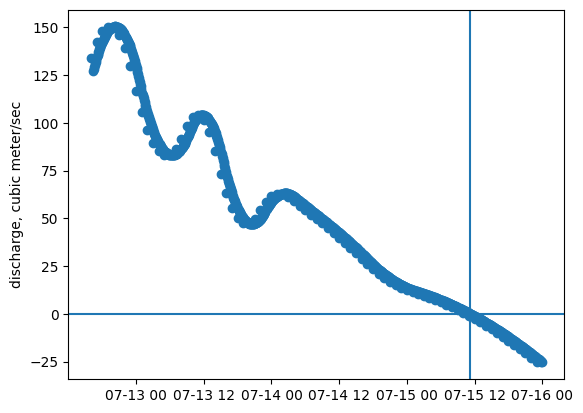

In [18]:
x = [12.614744365941817, 12.814506764288078, 13.028537672098178, 13.399524143522024, 13.642092723430304, 13.947800029240266, 14.170035411638388, 14.417598133151635, 14.721521630339682, 15.066825437899109, 15.508799131892868, 16.00642099255135, 16.407015682514725, 16.75231818373316, 17.351961356691724, 17.837098516508284, 18.35077269525253, 20.6195003180396, 18.878716036631108, 19.806182868361216, 19.363851890106677, 21.161711515711527, 21.71819187601779, 22.27467223632405, 22.873958778192335, 23.673008371577374, 24.70035672906586, 25.22829876410345, 25.71343592392001]
y = [150.95890410958904, 149.58904318613548, 148.01369967525952, 146.23287671232876, 145, 144.1215765966128, 143.42465962449165, 142.7294545630886, 142.13185036019104, 141.8013700720382, 141.66780968234966, 142.00000188122058, 142.7294545630886, 143.52568743980095, 145, 146.23287671232876, 147.32876921353275, 152.05479661079303, 148.35616647380672, 150.41096099435467, 149.4520558396431, 153.082193871067, 154.17808323690335, 155.20548049717735, 156.0958904109589, 157.1917829121629, 158.49315173005405, 158.97260273972603, 159.17808219178082]
pairs = sorted(list(zip(x,y)), key = lambda pair: pair[0])
x = [pair[0] for pair in pairs]
y = [- 5000000 * pair[1] / 3 for pair in pairs]
time_int = 300 / 60 / 60 / 24 # 300 seconds

xs_finals = []
# 12th, 16:21:55
start = 12 + 16/24 + 25/(24*60) 
curr = start
while curr < 16:
    xs_finals.append(curr)
    curr += time_int

volume_time_curve = scipy.interpolate.CubicSpline(x, y)
ys_finals = volume_time_curve.derivative()(xs_finals)

pairs = np.array(list(zip(xs_finals, ys_finals)))
# pairs = pairs[pairs[:,1] > 0]
xs_finals  = pairs[:,0]

xs_finals = [datetime.datetime(year = 2024, 
                        month = 7, 
                        day = int(x // 1), 
                        hour = int((x % 1 * 24) // 1),
                        minute = round(((x % 1 * 24) % 1 * 60)) % 60,
                        second = 0) for x in xs_finals]

ys_finals = pairs[:,1]
ys_finals /= 86400 # scales the discharge to m^3s^(-1)

fig, ax = plt.subplots()
ax.scatter(xs_finals, ys_finals)
ax.set_ylabel("discharge, cubic meter/sec")
ax.axvline(x = datetime.datetime(year = 2024, month = 7, day = 15, hour = 11, minute = 15, second = 33))
ax.axhline(y = 0)

discharge = dict(zip(xs_finals, ys_finals))



int(volume_time_curve.derivative().roots()[1] // 1)
(volume_time_curve.derivative().roots()[1] % 1) * 24 # 11
(volume_time_curve.derivative().roots()[1] % 1) * 24 % 1 * 60 # 15
(volume_time_curve.derivative().roots()[1] % 1) * 24 % 1 * 60 % 1 * 60 # 33

ref_date = datetime.datetime(year = 2024, month = 7, day = 15, hour = 11, minute = 15)
ref_date = np.datetime64(ref_date)

(np.float64(19916.0), np.float64(19920.0))

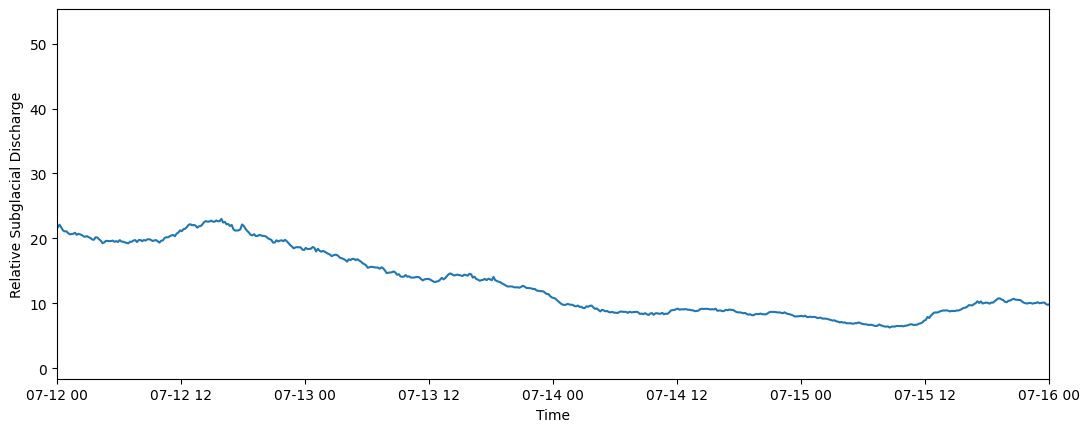

In [19]:
fig = plt.figure(figsize=(2*6.4,4.8))

plt.plot(df_ght.index, np.power(df_ght["mean"], 4/5))
plt.ylabel('Relative Subglacial Discharge')
plt.xlabel('Time')
plt.xlim(np.datetime64('2024-07-12'), np.datetime64('2024-07-16'))


In [20]:
# df_ght["discharge"] = df_ght.index.to_series().apply(lambda x: discharge[pd.to_datetime(x).to_pydatetime()])
# df_ght[0]
trimmed_df_ght = df_ght[(df_ght.index < datetime.datetime(2024, 7, 16)) & (df_ght.index > datetime.datetime(2024, 7, 12, 16, 20))]
trimmed_df_ght["discharge"] = trimmed_df_ght.index.to_series().apply(lambda x: discharge[pd.to_datetime(x).to_pydatetime()])
# ref_power = trimmed_df_ght.iloc[-77,:]["mean"]
trimmed_df_ght


,"((1, 4), QJT01)","((1, 4), QJT02)","((1, 4), QJT03)","((4, 7), QJT01)","((4, 7), QJT02)","((4, 7), QJT03)","((7, 10), QJT01)","((7, 10), QJT02)","((7, 10), QJT03)",mean,std,mean14,std14,mean47,std47,mean710,std710,discharge
2024-07-12 16:25:00,69.663067,63.752351,88.356700,54.776100,34.665624,75.699565,17.110586,12.474851,16.674090,48.130326,26.945268,73.924040,12.843692,55.047096,20.518313,15.419843,2.559758,127.307053
2024-07-12 16:35:00,69.663067,61.607725,88.356700,57.823689,34.665624,75.699565,17.284506,12.474851,16.674090,48.249980,26.896770,73.209164,13.722537,56.062959,20.573556,15.477816,2.618492,129.246246
2024-07-12 16:45:00,68.334492,59.886552,88.356700,57.823689,34.222626,71.766683,17.284506,12.474851,16.674090,47.424910,26.285684,72.192581,14.621935,54.604333,18.977941,15.477816,2.618492,131.100396
2024-07-12 16:55:00,67.082257,59.886552,88.356700,57.823689,33.955020,77.076829,17.284506,12.474851,16.674090,47.846055,26.791150,71.775170,14.803882,56.285179,21.602034,15.477816,2.618492,132.869505
2024-07-12 17:05:00,62.962376,59.484546,87.621636,53.708631,33.627358,71.766683,17.110586,12.087461,16.053973,46.047028,25.733131,70.022852,15.339873,53.034224,19.078605,15.084007,2.648315,134.553571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-15 23:15:00,27.325802,23.604191,33.930010,19.367456,11.576477,24.870566,7.316599,6.508479,6.757501,17.917453,9.632131,28.286667,5.229540,18.604833,6.679775,6.860860,0.413856,-23.679158
2024-07-15 23:25:00,27.325802,23.604191,33.930010,19.367456,11.576477,26.301147,7.316599,6.482636,6.733253,18.070841,9.763097,28.286667,5.229540,19.081693,7.366493,6.844163,0.427901,-24.077726
2024-07-15 23:35:00,27.325802,23.604191,33.930010,19.367456,11.576477,26.301147,7.316599,6.549286,6.579661,18.061181,9.774273,28.286667,5.229540,19.081693,7.366493,6.815182,0.434505,-24.478197
2024-07-15 23:45:00,26.354909,23.048183,32.941157,17.994553,10.546546,26.301147,7.316599,6.482636,6.287551,17.474809,9.571216,27.448083,5.036269,18.280749,7.881199,6.695595,0.546579,-24.880573


,"((1, 4), QJT01)","((1, 4), QJT02)","((1, 4), QJT03)","((4, 7), QJT01)","((4, 7), QJT02)","((4, 7), QJT03)","((7, 10), QJT01)","((7, 10), QJT02)","((7, 10), QJT03)",mean,std,mean14,std14,mean47,std47,mean710,std710,discharge
2024-07-12 16:25:00,69.663067,63.752351,88.356700,54.776100,34.665624,75.699565,17.110586,12.474851,16.674090,48.130326,26.945268,73.924040,12.843692,55.047096,20.518313,15.419843,2.559758,127.307053
2024-07-12 16:35:00,69.663067,61.607725,88.356700,57.823689,34.665624,75.699565,17.284506,12.474851,16.674090,48.249980,26.896770,73.209164,13.722537,56.062959,20.573556,15.477816,2.618492,129.246246
2024-07-12 16:45:00,68.334492,59.886552,88.356700,57.823689,34.222626,71.766683,17.284506,12.474851,16.674090,47.424910,26.285684,72.192581,14.621935,54.604333,18.977941,15.477816,2.618492,131.100396
2024-07-12 16:55:00,67.082257,59.886552,88.356700,57.823689,33.955020,77.076829,17.284506,12.474851,16.674090,47.846055,26.791150,71.775170,14.803882,56.285179,21.602034,15.477816,2.618492,132.869505
2024-07-12 17:05:00,62.962376,59.484546,87.621636,53.708631,33.627358,71.766683,17.110586,12.087461,16.053973,46.047028,25.733131,70.022852,15.339873,53.034224,19.078605,15.084007,2.648315,134.553571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-15 23:15:00,27.325802,23.604191,33.930010,19.367456,11.576477,24.870566,7.316599,6.508479,6.757501,17.917453,9.632131,28.286667,5.229540,18.604833,6.679775,6.860860,0.413856,-23.679158
2024-07-15 23:25:00,27.325802,23.604191,33.930010,19.367456,11.576477,26.301147,7.316599,6.482636,6.733253,18.070841,9.763097,28.286667,5.229540,19.081693,7.366493,6.844163,0.427901,-24.077726
2024-07-15 23:35:00,27.325802,23.604191,33.930010,19.367456,11.576477,26.301147,7.316599,6.549286,6.579661,18.061181,9.774273,28.286667,5.229540,19.081693,7.366493,6.815182,0.434505,-24.478197
2024-07-15 23:45:00,26.354909,23.048183,32.941157,17.994553,10.546546,26.301147,7.316599,6.482636,6.287551,17.474809,9.571216,27.448083,5.036269,18.280749,7.881199,6.695595,0.546579,-24.880573


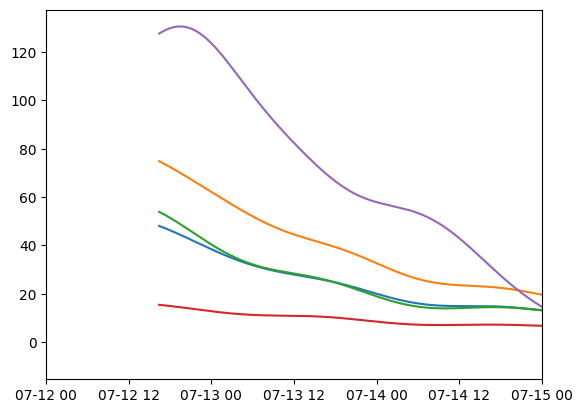

In [21]:
sos = scipy.signal.butter(4, 1/(86400), 'lp', fs = 1/600, output = 'sos')
filtered_tremor = scipy.signal.sosfiltfilt(sos, trimmed_df_ght["mean"])
filtered_tremor14 = scipy.signal.sosfiltfilt(sos, trimmed_df_ght["mean14"])
filtered_tremor47 = scipy.signal.sosfiltfilt(sos, trimmed_df_ght["mean47"])
filtered_tremor710 = scipy.signal.sosfiltfilt(sos, trimmed_df_ght["mean710"])
filtered_discharge = scipy.signal.sosfiltfilt(sos, trimmed_df_ght["discharge"])

# plt.plot(trimmed_df_ght.index, trimmed_df_ght["mean"])
plt.plot(trimmed_df_ght.index, filtered_tremor)
plt.plot(trimmed_df_ght.index, filtered_tremor14)
plt.plot(trimmed_df_ght.index, filtered_tremor47)
plt.plot(trimmed_df_ght.index, filtered_tremor710)
plt.plot(trimmed_df_ght.index, filtered_discharge)
plt.xlim(np.datetime64('2024-07-12'), np.datetime64('2024-07-15'))
trimmed_df_ght

/var/folders/5l/029x820d3hjgnct_bv_xsyzr0000gn/T/ipykernel_21064/3392648921.py:4: RuntimeWarning: invalid value encountered in log
  ax.scatter(np.log(filtered_tremor), np.log(filtered_discharge))


np.float64(-2.5804683650276967)

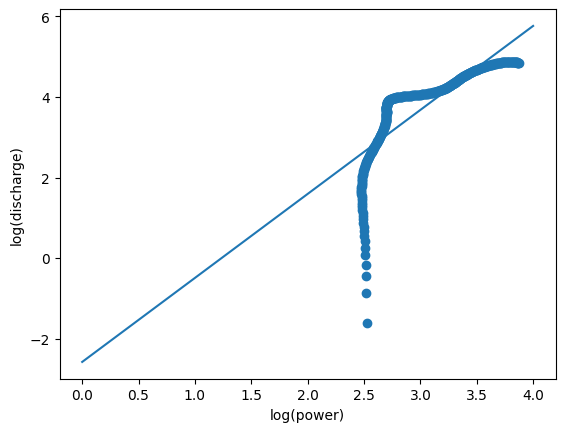

In [22]:
more_trimmed_df_ght = trimmed_df_ght[trimmed_df_ght["discharge"] > 0]

fig, ax = plt.subplots()
ax.scatter(np.log(filtered_tremor), np.log(filtered_discharge))
ax.set_xlabel("log(power)")
ax.set_ylabel("log(discharge)")
model_find_slope = scipy.stats.linregress(np.log(more_trimmed_df_ght["mean"]), np.log(more_trimmed_df_ght["discharge"]))
model_find_slope14 = scipy.stats.linregress(np.log(more_trimmed_df_ght["mean14"]), np.log(more_trimmed_df_ght["discharge"]))
model_find_slope47 = scipy.stats.linregress(np.log(more_trimmed_df_ght["mean47"]), np.log(more_trimmed_df_ght["discharge"]))
model_find_slope710 = scipy.stats.linregress(np.log(more_trimmed_df_ght["mean710"]), np.log(more_trimmed_df_ght["discharge"]))
plt.plot(range(5), model_find_slope.intercept + model_find_slope.slope * range(5))
power = model_find_slope.slope
power14 = model_find_slope14.slope
power47 = model_find_slope47.slope
power710 = model_find_slope710.slope
power
model_find_slope.intercept

np.float64(0.05454002304337226)

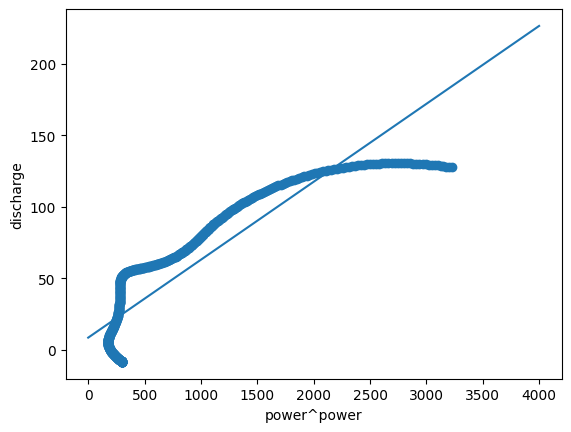

In [23]:
fig, ax = plt.subplots()
ax.scatter(np.power(filtered_tremor, power), filtered_discharge)
ax.set_xlabel("power^power")
ax.set_ylabel("discharge")
model_own_power = scipy.stats.linregress(np.power(trimmed_df_ght["mean"], power), trimmed_df_ght["discharge"])
model_own_power14 = scipy.stats.linregress(np.power(trimmed_df_ght["mean14"], power14), trimmed_df_ght["discharge"])
model_own_power47 = scipy.stats.linregress(np.power(trimmed_df_ght["mean47"], power47), trimmed_df_ght["discharge"])
model_own_power710 = scipy.stats.linregress(np.power(trimmed_df_ght["mean710"], power710), trimmed_df_ght["discharge"])
plt.plot(range(4000), model_own_power.intercept + model_own_power.slope * range(4000))

moe_own_power = model_own_power.stderr * 1.96
moe_own_power14 = model_own_power14.stderr * 1.96
moe_own_power47 = model_own_power47.stderr * 1.96
moe_own_power710 = model_own_power710.stderr * 1.96
model_own_power.slope

,"((1, 4), QJT01)","((1, 4), QJT02)","((1, 4), QJT03)","((4, 7), QJT01)","((4, 7), QJT02)","((4, 7), QJT03)","((7, 10), QJT01)","((7, 10), QJT02)","((7, 10), QJT03)",mean,std,mean14,std14,mean47,std47,mean710,std710
2023-08-03 00:05:00,NaN,NaN,12.609075,NaN,NaN,13.768526,NaN,NaN,7.411085,11.262895,2.764467,12.609075,NaN,13.768526,NaN,7.411085,NaN
2023-08-03 00:15:00,NaN,NaN,12.534464,NaN,NaN,13.662188,NaN,NaN,7.362309,11.186321,2.742898,12.534464,NaN,13.662188,NaN,7.362309,NaN
2023-08-03 00:25:00,NaN,NaN,12.609075,NaN,NaN,13.555850,NaN,NaN,7.313534,11.159486,2.746830,12.609075,NaN,13.555850,NaN,7.313534,NaN
2023-08-03 00:35:00,NaN,NaN,12.534464,NaN,NaN,13.473757,NaN,NaN,7.213730,11.073984,2.756415,12.534464,NaN,13.473757,NaN,7.213730,NaN
2023-08-03 00:45:00,NaN,NaN,12.459853,NaN,NaN,13.391663,NaN,NaN,7.113925,10.988481,2.766008,12.459853,NaN,13.391663,NaN,7.113925,NaN


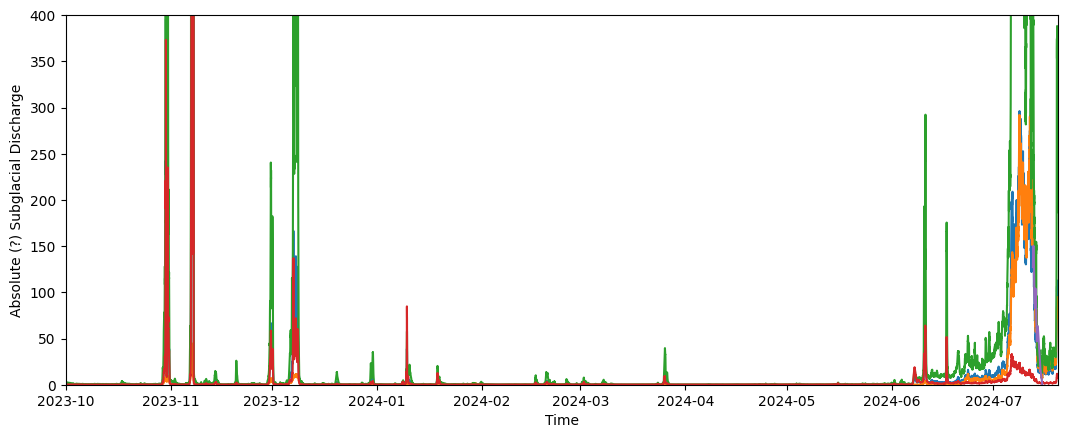

In [24]:
fig = plt.figure(figsize=(2*6.4,4.8))

plt.plot(df_ght.index, model_own_power.slope * np.power(df_ght["mean"], power))
plt.plot(df_ght.index, model_own_power14.slope * np.power(df_ght["mean14"], power))
plt.plot(df_ght.index, model_own_power47.slope * np.power(df_ght["mean47"], power))
plt.plot(df_ght.index, model_own_power710.slope * np.power(df_ght["mean710"], power))
# plt.plot(df_ght.index, (model_own_power.slope - moe_own_power) * np.power(df_ght["mean"], power))
# plt.plot(df_ght.index, (model_own_power.slope + moe_own_power) * np.power(df_ght["mean"], power))
plt.plot(more_trimmed_df_ght.index, more_trimmed_df_ght["discharge"])
plt.ylabel('Absolute (?) Subglacial Discharge')
plt.xlabel('Time')
plt.xlim(np.datetime64('2023-10-01'), np.datetime64('2024-07-20'))
plt.ylim(0, 400)

df_ght.head()

In [27]:
ols_df = pd.concat([trimmed_df_ght["discharge"], np.power(trimmed_df_ght["mean"], power)], axis = 1)

results = smf.ols('discharge ~ mean - 1', ols_df).fit()

ols_df14 = pd.concat([trimmed_df_ght["discharge"], np.power(trimmed_df_ght["mean14"], power14)], axis = 1)

results14 = smf.ols('discharge ~ mean14 - 1', ols_df14).fit()

ols_df47 = pd.concat([trimmed_df_ght["discharge"], np.power(trimmed_df_ght["mean47"], power47)], axis = 1)

results47 = smf.ols('discharge ~ mean47 - 1', ols_df47).fit()

ols_df710 = pd.concat([trimmed_df_ght["discharge"], np.power(trimmed_df_ght["mean710"], power710)], axis = 1)

results710 = smf.ols('discharge ~ mean710 - 1', ols_df710).fit()



In [30]:
results.params

mean    0.060264
dtype: float64

(0.0, 1000.0)

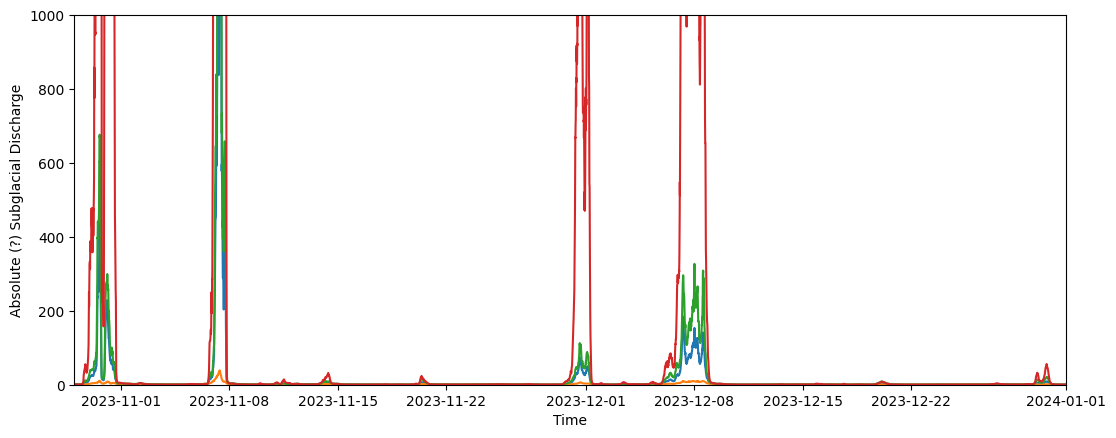

In [53]:
slope = results.params.iloc[0]
moe = results.bse.iloc[0] * 1.96

slope14 = results14.params.iloc[0]
slope47 = results47.params.iloc[0]
slope710 = results710.params.iloc[0]

fig = plt.figure(figsize=(2*6.4,4.8))

plt.plot(df_ght.index, slope * np.power(df_ght["mean"], power))
plt.plot(df_ght.index, slope14 * np.power(df_ght["mean14"], power14))
plt.plot(df_ght.index, slope47 * np.power(df_ght["mean47"], power47))
plt.plot(df_ght.index, slope710 * np.power(df_ght["mean710"], power710))
# plt.plot(df_ght.index, (slope - moe) * np.power(df_ght["mean"], power))
# plt.plot(df_ght.index, (slope + moe) * np.power(df_ght["mean"], power))
plt.plot(more_trimmed_df_ght.index, more_trimmed_df_ght["discharge"])
plt.ylabel('Absolute (?) Subglacial Discharge')
plt.xlabel('Time')
plt.xlim(np.datetime64('2023-10-29'), np.datetime64('2024-01-01'))
plt.ylim(0, 1000)

(0.0, 800.0)

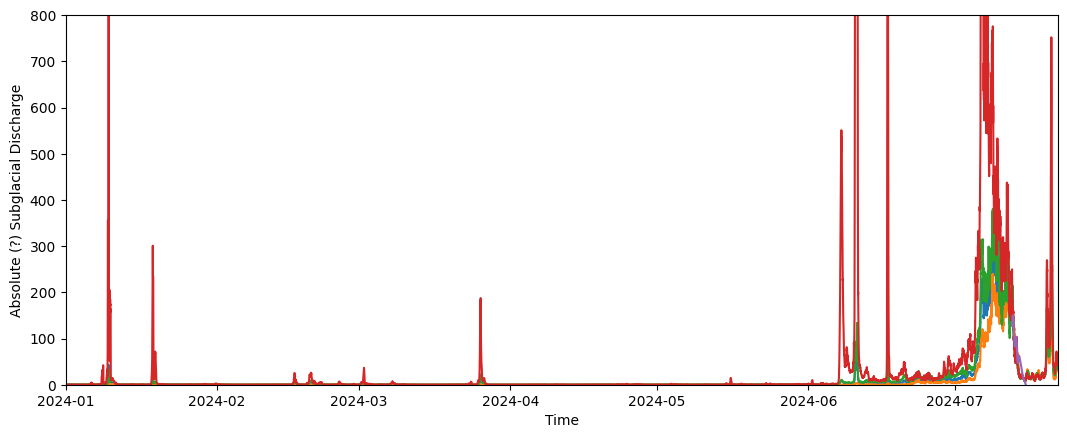

In [54]:
before = df_ght.loc[(df_ght.index <= '2023-10-29 00:00:00'), "mean"]
during = scipy.signal.medfilt(df_ght.loc[(df_ght.index > '2023-10-29 00:00:00') & (df_ght.index < '2024-01-01 00:00:00'), "mean"], 361)
after = df_ght.loc[(df_ght.index >= '2024-01-01 00:00:00'), "mean"]

before14 = df_ght.loc[(df_ght.index <= '2023-10-29 00:00:00'), "mean14"]
during14 = scipy.signal.medfilt(df_ght.loc[(df_ght.index > '2023-10-29 00:00:00') & (df_ght.index < '2024-01-01 00:00:00'), "mean14"], 361)
after14 = df_ght.loc[(df_ght.index >= '2024-01-01 00:00:00'), "mean14"]

before47 = df_ght.loc[(df_ght.index <= '2023-10-29 00:00:00'), "mean47"]
during47 = scipy.signal.medfilt(df_ght.loc[(df_ght.index > '2023-10-29 00:00:00') & (df_ght.index < '2024-01-01 00:00:00'), "mean47"], 361)
after47 = df_ght.loc[(df_ght.index >= '2024-01-01 00:00:00'), "mean47"]

before710 = df_ght.loc[(df_ght.index <= '2023-10-29 00:00:00'), "mean710"]
during710 = scipy.signal.medfilt(df_ght.loc[(df_ght.index > '2023-10-29 00:00:00') & (df_ght.index < '2024-01-01 00:00:00'), "mean710"], 361)
after710 = df_ght.loc[(df_ght.index >= '2024-01-01 00:00:00'), "mean710"]

smoothened = np.concatenate([before, during, after])
smoothened14 = np.concatenate([before14, during14, after14])
smoothened47 = np.concatenate([before47, during47, after47])
smoothened710 = np.concatenate([before710, during710, after710])

fig = plt.figure(figsize=(2*6.4,4.8))

plt.plot(df_ght.index, slope * np.power(smoothened, power))
plt.plot(df_ght.index, slope14 * np.power(smoothened14, power14))
plt.plot(df_ght.index, slope47 * np.power(smoothened47, power47))
plt.plot(df_ght.index, slope710 * np.power(smoothened710, power710))
# plt.plot(df_ght.index, (slope - moe) * np.power(smoothened, power))
# plt.plot(df_ght.index, (slope + moe) * np.power(smoothened, power))
plt.plot(more_trimmed_df_ght.index, more_trimmed_df_ght["discharge"])
plt.ylabel('Absolute (?) Subglacial Discharge')
plt.xlabel('Time')
plt.xlim(np.datetime64('2024-01-01'), np.datetime64('2024-07-22'))
plt.ylim(0, 800)

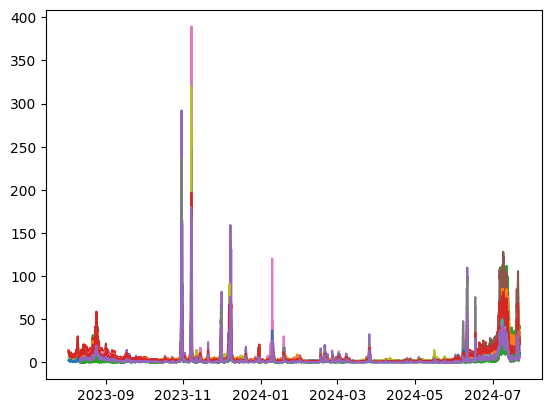

In [55]:
plt.plot(df_ght.index, df_ght[df_ght.columns[:-2]])

